In [1]:
import sys
sys.path.append("../")

from src.open_clip.factory import create_model_and_transforms, get_tokenizer
from src.training.precision import get_autocast

from os.path import join, exists
import torch

from PIL import Image
import numpy as np
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

import faiss


In [2]:
import os
from dotenv import load_dotenv
load_dotenv("../.env")


True

In [3]:
ROOT_DATA_DIR = os.path.join("..", os.getenv("ROOT_DATA_DIR", "data"))


In [4]:
model_arch_name = 'ViT-L-14' # or 'ViT-B-32'
ckpt_name = os.path.join("..", os.getenv("CKPT_PATH", "data/checkpoints/SkyCLIP_ViT_L14_top30pct_filtered_by_CLIP_laion_RS/epoch_20.pt"))
dataset_name = 'SkyScript'
caption_key = 'title_multi_objects'
data_csv_path = os.path.join("..", os.getenv("DATA_CSV_PATH", "data/dataset_csv/SkyScript_test_30K_filtered_by_CLIP_laion_RS.csv"))


In [6]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)


cpu


In [7]:
precision='amp'
batch_size = 128
autocast = get_autocast(precision)


In [ ]:
model, _, preprocess_val = create_model_and_transforms(
    model_arch_name,
    ckpt_name,
    precision=precision,
    device=device,
    output_dict=True,
    force_quick_gelu=True,
    # weights_only=True,
)
tokenizer = get_tokenizer(model_arch_name)


In [9]:
# model.eval()


In [10]:
class CsvDataset_image(Dataset):
    def __init__(self, df, transforms, img_key, return_img_path=False, root_data_dir=None):
        if root_data_dir is not None:
            df[img_key] = df[img_key].apply(lambda x: join(root_data_dir, x))
        self.images = df[img_key].tolist()
        self.transforms = transforms
        self.return_img_path = return_img_path

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        images = self.transforms(Image.open(str(self.images[idx])))
        if self.return_img_path:
            return images, str(self.images[idx])
        return images


In [11]:
df = pd.read_csv(data_csv_path)


In [12]:
df

,filepath,title,title_multi_objects,similarity_CLIP_laion_RS
0,images6/n984014847_CH_18.jpg,"a satellite image of road of bus stop, public ...",a satellite image of road of bus stop with pub...,0.254413
1,images7/w156335475_CH_21.jpg,"a satellite image of railway of rail, electrif...",a satellite image of railway of rail with elec...,0.248055
2,images7/a754696235_CH_21.jpg,"a satellite image of building of apartments, r...",a satellite image of building of apartments wi...,0.263733
3,images2/w381991727_ES_16.jpg,a satellite image of barrier of hedge,"a satellite image of barrier of hedge, surroun...",0.250572
4,images4/a190922025_US_21.jpg,"a satellite image of natural water, golf water...",a satellite image of natural water with golf w...,0.251767
...,...,...,...,...
29995,images3/n4970511180_US_18.jpg,a satellite image of addr street of Premium Ou...,a satellite image of addr street of Premium Ou...,0.261588
29996,images4/w145602351_FI_20.jpg,"a satellite image of surface of asphalt, onewa...",a satellite image of surface of asphalt with o...,0.251148
29997,images7/w41429166_DE_.jpg,"a satellite image of surface of asphalt, lanes...",a satellite image of surface of asphalt with l...,0.237147
29998,images6/a754045341_US_20.jpg,a satellite image of landuse of orchard,"a satellite image of landuse of orchard, surro...",0.247241


In [13]:
df['filepath'] = df['filepath'].apply(lambda x: join(ROOT_DATA_DIR, x))


In [ ]:
df.title.tolist()[:5], df.filepath.tolist()[:5]

In [15]:
df_image = df.groupby('filepath').count().reset_index()
df_text = df.groupby(caption_key).count().reset_index()
df_image.shape, df_text.shape

((30000, 4), (23017, 4))

In [16]:
exists_mask = df_image['filepath'].apply(exists)
missing = df_image[~exists_mask]
print(f"Skipping {len(missing)} missing files")
df_image = df_image[exists_mask].reset_index(drop=True)[:10000] # for testing purposes, limit to 10K images


Skipping 25962 missing files


In [18]:
len(df_image)

4038

In [19]:
# unique images
dataset_image = CsvDataset_image(
    df=df_image,
    transforms=preprocess_val,
    img_key='filepath',
    return_img_path=True,
)

# DataLoader for images
dataloader = DataLoader(dataset_image, batch_size=batch_size, shuffle=False, num_workers=0) # num_workers=4


In [ ]:
model.eval()
all_image_features = []
all_image_paths = []
with torch.no_grad():
    for batch in tqdm(dataloader, unit_scale=batch_size):
        images, img_paths = batch
        images = images.to(device=device)
        with autocast():
            image_features = model.encode_image(images, normalize=True)
            all_image_features.append(image_features.cpu())
            all_image_paths.extend(img_paths)
all_image_features = torch.cat(all_image_features)


In [21]:
all_image_features.shape, len(all_image_paths)


(torch.Size([4038, 768]), 4038)

In [22]:
# persist to disk
np.savez('skyscript_img_embeddings.npz', feats=all_image_features, paths=np.array(all_image_paths))


In [21]:
# load back
# data = np.load('skyscript_img_embeddings.npz', allow_pickle=True)
# all_image_features = data['feats']        # shape (N, D)
# all_image_paths = data['paths'].tolist()  # list of length N


In [23]:
# assume feats are already L2-normalized
D = all_image_features.shape[1]
index = faiss.IndexFlatIP(D)    # inner-product = cosine for normalized vectors
index.add(all_image_features)


In [24]:
def search(query:str, k=5):
    # 1) text to vector
    tokens = tokenizer([query])[0].to(device)
    with torch.no_grad():
        qv = model.encode_text(tokens.unsqueeze(0), normalize=True).cpu().numpy()
        print("Query vector shape:", qv.shape)
    # 2) search
    scores, idxs = index.search(qv, k)
    return [(all_image_paths[i], float(scores[0, j])) for j,i in enumerate(idxs[0])]


In [27]:
# example
# results = search("a single tree in an empty field", k=8)
# results = search("car in the road", k=8)
# results = search("car under trees", k=8)
# results = search("football field", k=8)
# results = search("ships and boats", k=8)
# results = search("cloud", k=8)
# results = search("letters in building", k=8)
# results = search("construction sites", k=8)
# results = search("islands", k=8)
# results = search("roundabouts", k=8)
# results = search("basketball court", k=8)
results = search("swimming pools", k=8)
# results = search("airport strips", k=8)
# results = search("airplanes", k=8)


for path, score in results:
    print(f"{score:.3f}  {path}")


Query vector shape: (1, 768)
0.254  /Users/bbhandar/github/ert_presentation/SkyScript/data/images2/a598595192_ES_16.jpg
0.252  /Users/bbhandar/github/ert_presentation/SkyScript/data/images2/a509164574_CH_21.jpg
0.249  /Users/bbhandar/github/ert_presentation/SkyScript/data/images2/a648730748_ES_16.jpg
0.249  /Users/bbhandar/github/ert_presentation/SkyScript/data/images2/a336684638_ES_16.jpg
0.247  /Users/bbhandar/github/ert_presentation/SkyScript/data/images2/a530098843_ES_18.jpg
0.246  /Users/bbhandar/github/ert_presentation/SkyScript/data/images2/a1067057203_CH_20.jpg
0.246  /Users/bbhandar/github/ert_presentation/SkyScript/data/images2/a542978001_ES_18.jpg
0.246  /Users/bbhandar/github/ert_presentation/SkyScript/data/images2/a515158730_ES_16.jpg


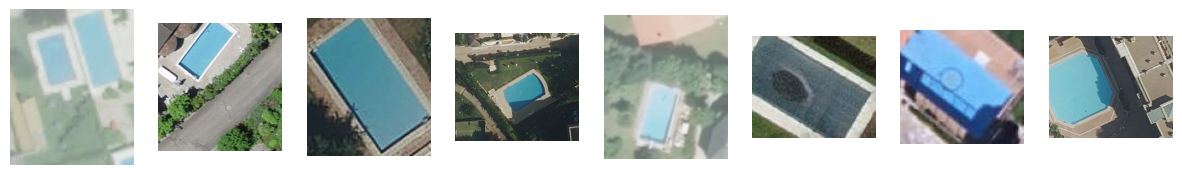

In [28]:
from PIL import Image
import matplotlib.pyplot as plt

paths, _ = zip(*results)
fig,axs = plt.subplots(1,len(paths), figsize=(15,3))
for ax,p in zip(axs, paths):
    ax.imshow(Image.open(p)); ax.axis('off')
plt.show()
